In [1]:
# 좋다! 미션 5 시작해보자!

# 계획서를 작성해보자
# 코드잇이 준 목차를 먼저 써보도록 하자

# <코드잇 목차>
# Part 1. 손상된 문서 복원 - CNN AE

# (완료)1-1 데이터 준비 
# -> 코랩형으로 되어있어서 vscode로 바꾸기
# -> print해서 보기(display 였다...)

# (완료)1-2 Data set구성 (금요일 기준 코스 하나씩 다시 뜯어보기)

# (완료)1-3. CNN 오토인코더 설계 
# -> 에폭 바꿔보기
# -> 문제가 생겼다. 모델에 계속 가중치가 쌓인다 이거 어떻게 해결하지?
# -> 하나의 셀 안에서 에폭이 돌게하면 모델에 가중치가 안쌓임

# (완료)1-4. 전체 이미지 복원과 평가


# (완료)1-5. 여기서부터는 여러분 차례입니다
# Baseline은 얕은 오토인코더라 흐릿한 얼룩 정도만 지웁니다. 아래 방향들을 실험하며 복원 품질을 높여 보세요.

# (완료)- 인코더/디코더를 더 깊게 쌓거나 채널 수를 늘려 보기 (BatchNorm 추가 포함) -> 해당 실험에 대한 결론 첨부도 완료
# (완료)- 인코더의 중간 출력을 디코더에 이어 주는 스킵 커넥션 추가해 보기
# - 좌우 반전, 밝기 조절 같은 데이터 증강 적용해 보기
# - 검증 세트를 나눠 과적합 여부를 확인하고, test 이미지 복원 결과 비교하기
# - 평가 지표에 PSNR을 추가하고, 복원이 잘 안 되는 손상 유형 분석하기


# [스프린트 미션 5] Baseline — CNN 오토인코더로 문서 복원하기 (+심화: ECG 이상 탐지)

이 노트북은 미션 5를 시작할 때 참고할 수 있는 Baseline 코드입니다.

> **주의**: Baseline 코드는 참고 자료일 뿐입니다. 그대로 제출하기보다는, 이 코드를 출발점 삼아 자신의 아이디어를 더하고 성능을 끌어올려 보세요. 모델 구조를 바꾸거나, 전처리를 개선하거나, 다른 손실 함수를 실험해 보는 것 모두 좋습니다.

- **Part 1 (기본 미션)**: 손상된 문서 이미지를 복원하는 CNN 오토인코더
- **Part 2 (심화, 채점 제외)**: 정상 심전도만 학습해 이상 심박을 찾아내는 LSTM 오토인코더


In [1]:
# 데이터 준비 / 라이브러리 불러오기

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 이미지 보고싶어서 넣은 추가 코드
from PIL import Image
from IPython.display import display

# 데이터 증강하려고 넣은 추가 코드
from torchvision.transforms import v2  # 이미지 전처리/변환
from torch.utils.data import DataLoader # 데이터를 배치로 나눠서 전달

# 저장소 위치
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
print("PyTorch:", torch.__version__, "| device:", device)

PyTorch: 2.14.0 | device: cpu


---
# Part 1. 손상된 문서 복원 — CNN 오토인코더

train(손상 이미지)과 train_cleaned(원본 이미지)를 한 쌍으로 학습합니다.
손상 이미지를 입력하면 원본에 가까운 이미지를 출력하도록 인코더-디코더를 학습시키는 구조예요.

## 1-1. 데이터 준비 (VS Code)
이미 내려받아 압축을 푼 로컬 데이터를 사용합니다. 코랩 업로드나 Kaggle API 인증은 필요하지 않습니다.

1. VS Code에서 `Mission_5` 폴더를 열고 이 노트북의 Python 커널을 선택하세요.
2. `Mission_5/denoising-dirty-documents/` 안에 `train`, `train_cleaned`, `test` 폴더가 있는지 확인하세요.
3. 아래 셀을 실행하세요. 다른 위치에 데이터를 저장했다면 `DATA_DIR`을 해당 폴더의 절대 경로로 지정하세요.


In [5]:
from pathlib import Path # pathlib 내 컴퓨터 파일이나 폴더의 경로를 찾아주는 파이썬 기본 라이브러리, path가 경로

# VS Code에서 Mission_5 또는 상위 CodeIt-ouo 폴더를 열었을 때의 경로입니다.

PROJECT_DIR = Path.cwd() # cwd는 현재 작업 폴더라는 뜻
if not (PROJECT_DIR / "denoising-dirty-documents").is_dir(): # 만약 현재 작업 폴더에 이 폴더가 없다면
    if (PROJECT_DIR / "Mission_5" / "denoising-dirty-documents").is_dir(): # 여기있는지 확인하시고
        PROJECT_DIR = PROJECT_DIR / "Mission_5" # 얘가 기준이 되서 프로젝트 기준 경로로 설정합니다.

DATA_DIR = PROJECT_DIR / "denoising-dirty-documents" 
'''훈련데이터와 테스트, 정답까지 모두 담겨있는 상위폴더'''

# 데이터가 다른 위치에 있다면 위 줄 대신 절대 경로를 지정하세요.
# DATA_DIR = Path("/Users/사용자이름/데이터폴더/denoising-dirty-documents")

# 데이터 폴더별 경로 지정
TRAIN_DIR = DATA_DIR / "train"
CLEAN_DIR = DATA_DIR / "train_cleaned"
TEST_DIR = DATA_DIR / "test"

# 제대로 폴더가 준비됬는지 확인하는 for 문 / 안전장치
for folder in (TRAIN_DIR, CLEAN_DIR, TEST_DIR):
    if not folder.is_dir(): # 만약에 폴더가 없다면
        raise FileNotFoundError( # 이런 안내문구를 띄워드림
            f"데이터 폴더가 없습니다: {folder}\n"
            "압축을 풀었는지 확인하고 DATA_DIR을 실제 데이터 경로로 수정하세요."
        )
    images = sorted(folder.glob("*.png"))
    # 이미지경로 저장 = 경로들을 이름순으로 정렬하기(폴더에서 ("* 무엇이든 괜찮다. png 파일을 찾아라"))
    if not images: # 만약 이미지가 없다면
        raise FileNotFoundError(f"PNG 이미지가 없습니다: {folder}") # 오류가 발생되고 이런 안내 문구를 띄워드림
    print(f"{folder.name}: {len(images)}장") # 잘했다면 각 폴더별로 몇장있는지 보여드림

print("데이터 경로:", DATA_DIR.resolve()) # 저장되어 있는 데이터 폴더 경로


train: 144장
train_cleaned: 144장
test: 72장
데이터 경로: /Users/codeit/CodeIt-ouo/Mission_5/denoising-dirty-documents


In [6]:
# 한번 찍어보자! - 학습데이터

clean_images = sorted(TRAIN_DIR.glob("*.png"))
'''여기에 뭐가 있는지 확인하는 명령어'''
clean_images[:5]


[PosixPath('/Users/codeit/CodeIt-ouo/Mission_5/denoising-dirty-documents/train/101.png'),
 PosixPath('/Users/codeit/CodeIt-ouo/Mission_5/denoising-dirty-documents/train/102.png'),
 PosixPath('/Users/codeit/CodeIt-ouo/Mission_5/denoising-dirty-documents/train/104.png'),
 PosixPath('/Users/codeit/CodeIt-ouo/Mission_5/denoising-dirty-documents/train/105.png'),
 PosixPath('/Users/codeit/CodeIt-ouo/Mission_5/denoising-dirty-documents/train/107.png')]

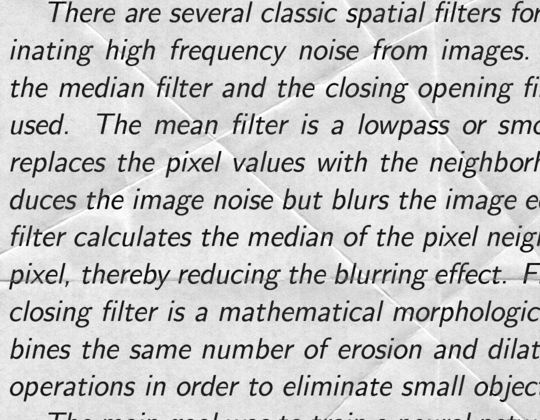

In [7]:
# 위에 출력물 기준으로 찍어보기
display(Image.open(TRAIN_DIR / "102.png"))

In [8]:
clean_images_1 = sorted(CLEAN_DIR.glob("*.png"))
clean_images_1[:5]

[PosixPath('/Users/codeit/CodeIt-ouo/Mission_5/denoising-dirty-documents/train_cleaned/101.png'),
 PosixPath('/Users/codeit/CodeIt-ouo/Mission_5/denoising-dirty-documents/train_cleaned/102.png'),
 PosixPath('/Users/codeit/CodeIt-ouo/Mission_5/denoising-dirty-documents/train_cleaned/104.png'),
 PosixPath('/Users/codeit/CodeIt-ouo/Mission_5/denoising-dirty-documents/train_cleaned/105.png'),
 PosixPath('/Users/codeit/CodeIt-ouo/Mission_5/denoising-dirty-documents/train_cleaned/107.png')]

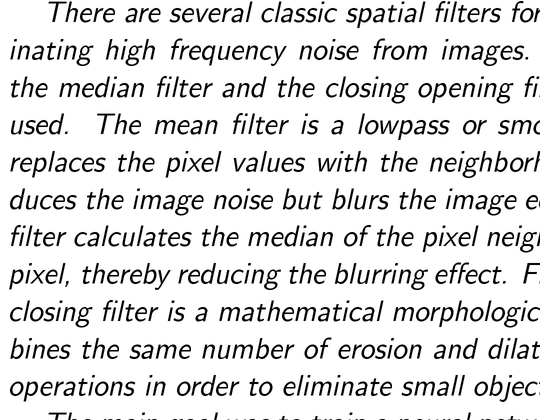

In [9]:
# 한번 찍어보자! - 클린데이터
display(Image.open(CLEAN_DIR / "102.png"))

## 1-2. Dataset 구성
이미지 크기가 두 종류(420×540, 258×540)라서, 학습할 때는 **같은 위치에서 128×128 패치를 잘라** 손상/원본 쌍으로 사용합니다.
패치 단위로 학습하면 이미지 크기를 신경 쓰지 않아도 되고, 한 이미지에서 매번 다른 부분을 보게 되어 데이터가 늘어나는 효과도 있어요.

In [10]:
import os # 파이썬과 내컴퓨터 연결하기
import random # 무작위로 위치선택할때 
from PIL import Image # 파이썬에서 이미지 수정하는 도구 Python Imaging Library / PIL: 이미지 도구들이 들어이는 라이브러리 중에 Image만 다루겠어!
from torch.utils.data import Dataset, DataLoader # 불러오고 줄세우고 모델한테 전달하고
import torchvision.transforms.functional as TF # 이미지를 자르고 텐서로 바꾸는 이미지 변환 도구 상자


class DirtyDocsDataset(Dataset):
    """손상 이미지와 원본 이미지에서 같은 위치의 패치를 한 쌍으로 돌려줍니다."""

    def __init__(self, dirty_dir, clean_dir, crop_size=128):
        self.dirty_dir = dirty_dir
        self.clean_dir = clean_dir
        self.files = sorted(path.name for path in Path(dirty_dir).glob("*.png"))
        self.crop_size = crop_size

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        name = self.files[idx]
        dirty = Image.open(os.path.join(self.dirty_dir, name)).convert("L")
        clean = Image.open(os.path.join(self.clean_dir, name)).convert("L")

        # 두 이미지에서 '같은 위치'를 잘라야 하므로 crop 좌표를 직접 뽑습니다.
        cs = self.crop_size
        top = random.randint(0, dirty.height - cs)
        left = random.randint(0, dirty.width - cs)
        dirty = TF.to_tensor(TF.crop(dirty, top, left, cs, cs))  # (1, 128, 128), 0~1
        clean = TF.to_tensor(TF.crop(clean, top, left, cs, cs))
        return dirty, clean


train_dataset = DirtyDocsDataset(TRAIN_DIR, CLEAN_DIR)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
print("훈련 이미지 수:", len(train_dataset))

훈련 이미지 수: 144


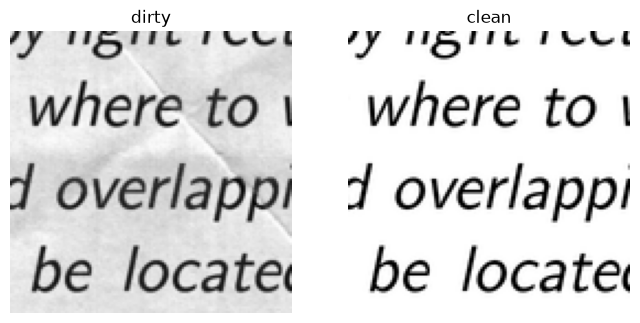

In [11]:
# 손상/원본 쌍이 잘 만들어졌는지 확인해 봅시다.
dirty, clean = train_dataset[0]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(dirty.squeeze(), cmap="gray"); axes[0].set_title("dirty")
axes[1].imshow(clean.squeeze(), cmap="gray"); axes[1].set_title("clean")
for ax in axes: ax.axis("off")
plt.show()

#### 데이터 증강 전, train 데이터에서 val 데이터 나누기

In [12]:
# 의사코드

# 1. 데이터 나누기 (train 80%, val 20%) -> 짝맞춰 놓은거 그대로 해야됨 train_dataset = DirtyDocsDataset(TRAIN_DIR, CLEAN_DIR)
# 1-1. train을 full로 바꿈
# 2. 둘다 증강 실시 1-5 시작

# 데이터 나누기 -> codeit 강의 6-6에 있음
from torch.utils.data import random_split # 데이터를 랜덤하게 나누는 기능 불러오기
full_dataset = DirtyDocsDataset(TRAIN_DIR, CLEAN_DIR)
'''데이터 나누기 할때 위 셸 일부 그대로 사용'''
train_dataset, val_dataset = random_split(full_dataset, [0.8, 0.2]) # 전체 데이터를 학습용 80%, 검증용 20%로 나누기

# 학습용 데이터셋 사용 
train_dataloader = DataLoader(dataset=train_dataset, batch_size=16, shuffle=True, drop_last=True)

# 검증용(모의고사) 데이터셋 사용 
val_dataloader = DataLoader(dataset=val_dataset, batch_size=16)

print("훈련 이미지 수:", len(train_dataloader))
print("검증 이미지 수:", len(val_dataloader))

훈련 이미지 수: 7
검증 이미지 수: 2


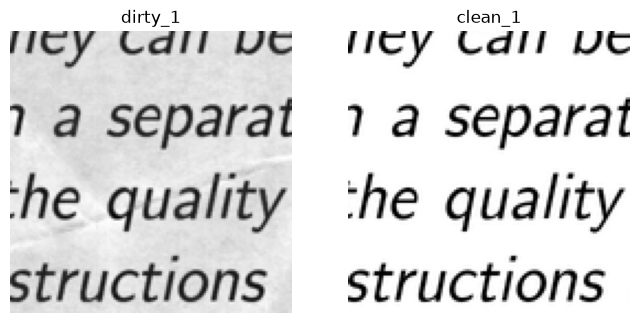

In [13]:
# 1-2 시각화 그대로 사용하기
# 1. 변수명은 _1 추가
# 2. train_dataset -> full_dataset으로 변경
# 3. 출력해보고 이상하면 수정

dirty_1, clean_1 = full_dataset[0]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(dirty_1.squeeze(), cmap="gray"); axes[0].set_title("dirty_1")
axes[1].imshow(clean_1.squeeze(), cmap="gray"); axes[1].set_title("clean_1")
for ax in axes: ax.axis("off")
plt.show()

#### 데이터 증강하기 - 좌우 변경 시각화해보기

In [14]:
# 의사코드
# o필요한 라이브러리 불러오기 from torchvision.transforms import v2
# 데이터 가져오고 full_dataset
# 좌우 반전에 필요한 코드 가져오기
# 프린트해서 잘됬는지 확인

def visualize(full_dataset, transform):
    fig, axes = plt.subplots(2, 2, figsize=(6, 6))

    axes = axes.flatten()
    for ax in axes:
        ax.imshow(transform(full_dataset).squeeze(),cmap="gray") # 한장꺼내기가 빠졌었음 squeeze로 차원 줄이고 컬러 회색으로 변경
        ax.axis('off')

    plt.show()

hor_flip = v2.RandomHorizontalFlip(p=0.5)

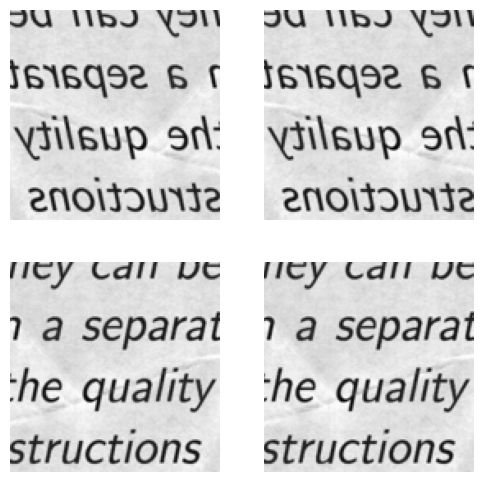

In [15]:
visualize(dirty_1, hor_flip)

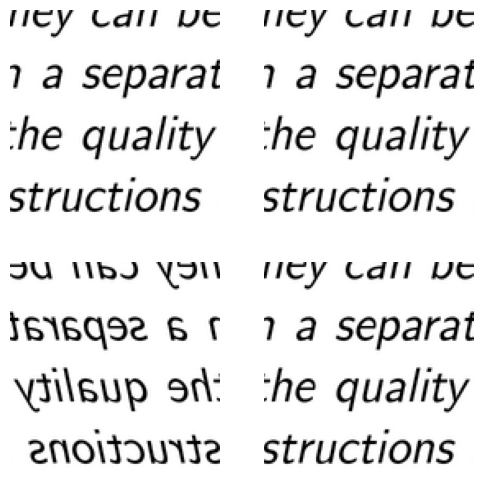

In [16]:
visualize(clean_1, hor_flip)

### 실전 데이터 증강

In [17]:
# 실전 데이터 증강 - 좌우변환해주기

# full_dataset 데이터 활용해서 dataset 짝만들기
# 라이브러리는 불러왔으니 v2 사용해서 좌우 반전 넣어보기
# 클래스 사용해서 데이터 좌우반전 뼈대만들기
# 전체 돌려서 RMSE 수치 변화 확인하기
# 되돌아가서 이제 밝기 조절도 추가하기

# full_dataset 데이터 활용해서 dataset 짝만들기
augment_transform = v2.Compose(
  [
    v2.ToImage(),
    v2.RandomHorizontalFlip(),
  ]
)
class AugmentedPairDataset(Dataset): # 클래스 사용해서 데이터 좌우반전 뼈대만들기
    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        dirty_1, clean_1 = self.base_dataset[idx]

        pair = torch.stack([dirty_1, clean_1])
        pair = self.transform(pair)

        dirty_1 = pair[0]
        clean_1 = pair[1]

        return dirty_1, clean_1

# 학습에만 필요한니깐 val은 묶으면 안됨
augmented_train_dataset = AugmentedPairDataset(
    train_dataset,
    augment_transform
)


In [18]:
# 잘되는지 확인하기
# 위에서 데이터 짝지어서 반전시킴

dirty_aug, clean_aug = augmented_train_dataset[0]

print("dirty 모양:", dirty_aug.shape)
print("clean 모양:", clean_aug.shape)

dirty 모양: torch.Size([1, 128, 128])
clean 모양: torch.Size([1, 128, 128])


In [19]:
# 학습을 시켜보자

train_loader = DataLoader(
    augmented_train_dataset,
    batch_size=16, #기존에도 16이였으니깐 그대로 16사용하기
    shuffle=True
)
dirty_batch, clean_batch = next(iter(train_loader))

print("dirty 배치 모양:", dirty_batch.shape)
print("clean 배치 모양:", clean_batch.shape)

dirty 배치 모양: torch.Size([16, 1, 128, 128])
clean 배치 모양: torch.Size([16, 1, 128, 128])


## 1-3. CNN 오토인코더 설계
`Conv2d`(stride=2)로 크기를 절반씩 줄이며 특징을 압축하고, `ConvTranspose2d`로 다시 원래 크기까지 복원합니다.
층마다 텐서 크기가 어떻게 변하는지 주석으로 적어 두세요. 인코더와 디코더의 크기가 어긋나는 문제가 이 미션에서 가장 자주 만나는 에러입니다.

In [20]:
class ConvDenoiser(nn.Module): 
    # ConvDenoiser라는 이름으로 모델 뼈대 맞추기
    # Module 모델이 갖춰야할 기본 소양을 입력, 물려받기
    def __init__(self): # 어떤 모델 만들지 부품을 준비하자!
        super().__init__() # nn.Module 스위치 온!
        self.encoder = nn.Sequential( # self로 모델 살붙이기
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),   # (1, 128, 128) -> (32, 64, 64)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # (32, 64, 64) -> (64, 32, 32)
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # (64, 32, 32) -> (32, 64, 64)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),   # (32, 64, 64) -> (1, 128, 128)
            nn.Sigmoid(),  # 픽셀 값을 0~1 범위로
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


# 가중치가 여기에 쌓여서 셸 이동해서 안쌓이게 바꾸기 -> 코드잇 코드라 이동안하고 주석처리
#model = ConvDenoiser().to(device)
#print(model)

In [21]:
model = ConvDenoiser().to(device) # <- 이동하므로써 에폭이 이 전체 셀을 학습하게 돌리는거라 가중치가 안쌓임
print(model)

criterion = nn.MSELoss()
'''사용할 손실함수의 이름'''
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
'''아담을 사용해서 계산'''

EPOCHS = 50 # 전체 학습 몇번?
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    for dirty, clean in train_loader:
        dirty, clean = dirty.to(device), clean.to(device)
        optimizer.zero_grad()
        restored = model(dirty)
        loss = criterion(restored, clean)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(dirty)
    if (epoch + 1) % 5 == 0:
        print(f"epoch {epoch + 1:3d} | loss {epoch_loss / len(train_dataset):.5f}")

ConvDenoiser(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): Sigmoid()
  )
)
epoch   5 | loss 0.08149
epoch  10 | loss 0.05496
epoch  15 | loss 0.02919
epoch  20 | loss 0.02137
epoch  25 | loss 0.01579
epoch  30 | loss 0.01187
epoch  35 | loss 0.00978
epoch  40 | loss 0.00825
epoch  45 | loss 0.00729
epoch  50 | loss 0.00648


## 1-4. 전체 이미지 복원과 평가
학습은 128×128 패치로 했지만, 합성곱 모델은 입력 크기가 달라도 동작합니다.
다만 stride=2 층을 두 번 지나므로 가로/세로가 4의 배수여야 해요. 4의 배수가 아닌 이미지(258×540)는 가장자리를 패딩했다가 복원 후 잘라냅니다.

RMSE: 0.0553


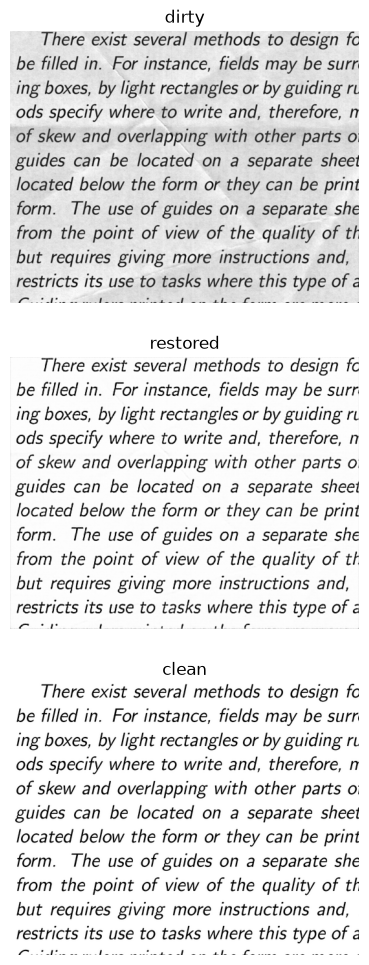

In [22]:
def denoise_full_image(model, img_tensor, multiple=4):
    """크기가 4의 배수가 아니면 오른쪽/아래를 패딩한 뒤 복원하고, 원래 크기로 되돌립니다."""
    _, h, w = img_tensor.shape
    pad_h = (multiple - h % multiple) % multiple
    pad_w = (multiple - w % multiple) % multiple
    x = F.pad(img_tensor.unsqueeze(0), (0, pad_w, 0, pad_h), mode="reflect")
    model.eval()
    with torch.no_grad():
        out = model(x.to(device)).cpu()
    return out[0, :, :h, :w]


# 훈련 이미지 하나를 통째로 복원해 봅니다.
name = full_dataset.files[0]
dirty_full = TF.to_tensor(Image.open(TRAIN_DIR / name).convert("L"))
clean_full = TF.to_tensor(Image.open(CLEAN_DIR / name).convert("L"))
restored_full = denoise_full_image(model, dirty_full)

rmse = torch.sqrt(((restored_full - clean_full) ** 2).mean())
print(f"RMSE: {rmse:.4f}")

fig, axes = plt.subplots(3, 1, figsize=(10, 12))
for ax, img, title in zip(axes, [dirty_full, restored_full, clean_full], ["dirty", "restored", "clean"]):
    ax.imshow(img.squeeze(), cmap="gray"); ax.set_title(title); ax.axis("off")
plt.show()

In [23]:
# 위에서 한장만 본거니깐 전체 수를 봅시다.
model.eval()

total_squared_error = 0
total_pixels = 0

with torch.no_grad():
    for dirty, clean in val_dataloader:
        dirty = dirty.to(device)
        clean = clean.to(device)

        restored = model(dirty)

        total_squared_error += ((restored - clean) ** 2).sum().item()
        total_pixels += clean.numel()

val_rmse = (total_squared_error / total_pixels) ** 0.5
print(f"검증 세트 전체 RMSE: {val_rmse:.4f}")

검증 세트 전체 RMSE: 0.0808


좌우 반전 증강을 적용한 기본 2층 모델에서 에폭을 30에서 50으로 늘리자 RMSE가 0.0564에서 0.0479로 감소했다. 학습 횟수를 늘린 것이 복원 성능 향상에 도움을 준 것으로 보인다.

## 1-5. 여기서부터는 여러분 차례입니다
Baseline은 얕은 오토인코더라 흐릿한 얼룩 정도만 지웁니다. 아래 방향들을 실험하며 복원 품질을 높여 보세요.
- 인코더/디코더를 더 깊게 쌓거나 채널 수를 늘려 보기 (BatchNorm 추가 포함)
- 인코더의 중간 출력을 디코더에 이어 주는 스킵 커넥션 추가해 보기
- 좌우 반전, 밝기 조절 같은 데이터 증강 적용해 보기
- 검증 세트를 나눠 과적합 여부를 확인하고, test 이미지 복원 결과 비교하기
- 평가 지표에 PSNR을 추가하고, 복원이 잘 안 되는 손상 유형 분석하기

### - 인코더/디코더를 더 깊게 쌓거나 채널 수를 늘려 보기 (BatchNorm 추가 포함)

In [24]:
# 의사코드

# 1. 1-3 전체 셀을 복재한다.
# 2. 변수 이름 변경 : ConvDenoiser → ImprovedDenoiser : 모델 구조 이름 / model → improved_model : 실제 모델 변수 / optimizer → improved_optimizer : 개선 모델을 학습시키는 도구 
# 3. 층 2개 더 넣어보기
# 4. 하하,... 1-4 도 복제해서 RMSE랑 시각화도 비교해야되는구나..
# 5. 성능비교 

# from torch.utils.data import random_split
# full_dataset = DirtyDocsDataset(TRAIN_DIR, CLEAN_DIR)

class ImprovedDenoiser(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),   # (1, 128, 128) -> (32, 64, 64)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # (32, 64, 64) -> (64, 32, 32)
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # (16, 32, 32) -> (32, 16, 16)
            nn.ReLU(),
            # nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),  # (16, 16, 8) -> (16, 8, 8)
            # nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            # nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # (16, 16, 8) -> (16, 8, 8)
            # nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),   # (16, 32, 32) -> (32, 16, 16)
            nn.ReLU(),  
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # (32, 64, 64) -> (64, 32, 32)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),  # (1, 128, 128) -> (32, 64, 64)
            nn.Sigmoid(), # 픽셀 값을 0~1 범위로
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

In [25]:
# ConvDenoiser → ImprovedDenoiser : 모델 구조 이름 / model → improved_model : 실제 모델 변수 / optimizer → improved_optimizer : 개선 모델을 학습시키는 도구 

improved_model = ImprovedDenoiser().to(device) # <- 이동하므로써 에폭이 이 전체 셀을 학습하게 돌리는거라 가중치가 안쌓임
print(improved_model)

criterion = nn.MSELoss()
improved_optimizer = torch.optim.Adam(improved_model.parameters(), lr=1e-3)

EPOCHS = 30
for epoch in range(EPOCHS):
    improved_model.train()
    epoch_loss = 0.0
    for dirty, clean in train_loader:
        dirty, clean = dirty.to(device), clean.to(device)
        improved_optimizer.zero_grad()
        restored = improved_model(dirty)
        loss = criterion(restored, clean)
        loss.backward()
        improved_optimizer.step()
        epoch_loss += loss.item() * len(dirty)
    if (epoch + 1) % 5 == 0:
        print(f"epoch {epoch + 1:3d} | loss {epoch_loss / len(train_dataset):.5f}")

ImprovedDenoiser(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Sigmoid()
  )
)
epoch   5 | loss 0.08435
epoch  10 | loss 0.08560
epoch  15 | loss 0.08421
epoch  20 | loss 0.08472
epoch  25 | loss 0.08500
epoch  30 | loss 0.08353


RMSE: 0.2010


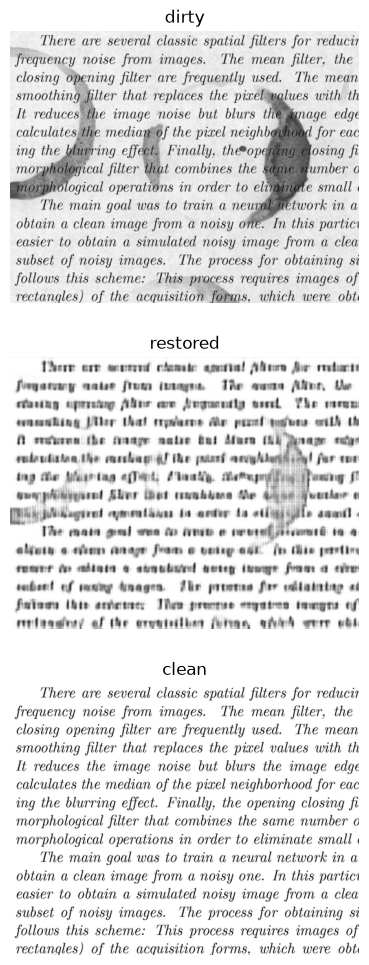

In [40]:
# ConvDenoiser → ImprovedDenoiser : 모델 구조 이름 / model → improved_model : 실제 모델 변수 / optimizer → improved_optimizer : 개선 모델을 학습시키는 도구 

def denoise_full_image(improved_model, img_tensor, multiple=8):
    """크기가 4의 배수가 아니면 오른쪽/아래를 패딩한 뒤 복원하고, 원래 크기로 되돌립니다."""
    _, h, w = img_tensor.shape
    pad_h = (multiple - h % multiple) % multiple
    pad_w = (multiple - w % multiple) % multiple
    x = F.pad(img_tensor.unsqueeze(0), (0, pad_w, 0, pad_h), mode="reflect")
    improved_model.eval()
    with torch.no_grad():
        out = improved_model(x.to(device)).cpu()
    return out[0, :, :h, :w]


# 모의고사 해봅시다.
name = full_dataset.files[val_dataset.indices[0]]
dirty_full = TF.to_tensor(Image.open(TRAIN_DIR / name).convert("L"))
clean_full = TF.to_tensor(Image.open(CLEAN_DIR / name).convert("L"))
restored_full = denoise_full_image(improved_model, dirty_full)

rmse = torch.sqrt(((restored_full - clean_full) ** 2).mean())
print(f"RMSE: {rmse:.4f}")

fig, axes = plt.subplots(3, 1, figsize=(10, 12))
for ax, img, title in zip(axes, [dirty_full, restored_full, clean_full], ["dirty", "restored", "clean"]):
    ax.imshow(img.squeeze(), cmap="gray"); ax.set_title(title); ax.axis("off")
plt.show()

In [26]:
print(restored_full.min().item(), restored_full.max().item())

0.00496935099363327 0.9999188184738159


층 4개, 에폭 30 / 실험 실패 -> 0.9390987157821655 1.0 가 나오면서 흰색만 나옴

층 4개, 에폭 10, 15 / loss가  0.22에서 멈춤 더이상 줄지 않음, 에폭의 문제가 아니라 층수가 너무 많음

층 3개, 에폭 30 / 이번엔 회색으로 나옴

#### 결론 : 층을 4개로 늘리면 loss 계산이 미세하게 줄어들어 EPOCH를 늘려봤지만 일정 수준에서 loss 계산이 멈춤, 3층을 바꿔봤지만 이번엔 restored가 회색으로 바뀜 따라서 층을 늘린다고 loss 가 개선되지 않음



### - 인코더의 중간 출력을 디코더에 이어 주는 스킵 커넥션 추가해 보기

강사님에게 쫄라버렸다... 호호
def forward <- 여기서 아래 코드 잘 넣어보셈
torch.cat([d2, e1], dim=1)
d2 + e1

In [27]:
# ConvDenoiser → ImprovedDenoiser_1 : 모델 구조 이름 / model → improved_model_1 : 실제 모델 변수 / optimizer → improved_optimizer_1 : 개선 모델을 학습시키는 도구 

# 의사코드

# 1. 1-3~1-4 모델 변수 이름 _1넣어서 수정
# 2. 1-3 강사님이 스무고개로 주신 코드 넣어서 비교
# 3. 비교 후, 결과 작성

class ImprovedDenoiser_1(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),   # (1, 128, 128) -> (32, 64, 64)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # (32, 64, 64) -> (64, 32, 32)
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # (64, 32, 32) -> (32, 64, 64)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),   # (32, 64, 64) -> (1, 128, 128)
            nn.Sigmoid(),  # 픽셀 값을 0~1 범위로
        )

    def forward(self, x):
        e1 = self.encoder[:2](x)
        e2 = self.encoder[2:](e1)
        d2 = self.decoder[:2](e2)
        skip_use = d2 + e1
        return self.decoder[2:](skip_use)


In [28]:
# ConvDenoiser → ImprovedDenoiser_1 : 모델 구조 이름 / model → improved_model_1 : 실제 모델 변수 / optimizer → improved_optimizer_1 : 개선 모델을 학습시키는 도구 


improved_model_1 = ImprovedDenoiser_1().to(device) # <- 이동하므로써 에폭이 이 전체 셀을 학습하게 돌리는거라 가중치가 안쌓임
print(improved_model_1)

criterion = nn.MSELoss()
improved_optimizer_1 = torch.optim.Adam(improved_model_1.parameters(), lr=1e-3)

EPOCHS = 50
for epoch in range(EPOCHS):
    improved_model_1.train()
    epoch_loss = 0.0
    for dirty, clean in train_loader:
        dirty, clean = dirty.to(device), clean.to(device)
        improved_optimizer_1.zero_grad()
        restored = improved_model_1(dirty)
        loss = criterion(restored, clean)
        loss.backward()
        improved_optimizer_1.step()
        epoch_loss += loss.item() * len(dirty)
    if (epoch + 1) % 5 == 0:
        print(f"epoch {epoch + 1:3d} | loss {epoch_loss / len(train_dataset):.5f}")

ImprovedDenoiser_1(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): Sigmoid()
  )
)
epoch   5 | loss 0.07574
epoch  10 | loss 0.05554
epoch  15 | loss 0.03214
epoch  20 | loss 0.02216
epoch  25 | loss 0.01730
epoch  30 | loss 0.01189
epoch  35 | loss 0.00984
epoch  40 | loss 0.00818
epoch  45 | loss 0.00681
epoch  50 | loss 0.00608


RMSE: 0.0591


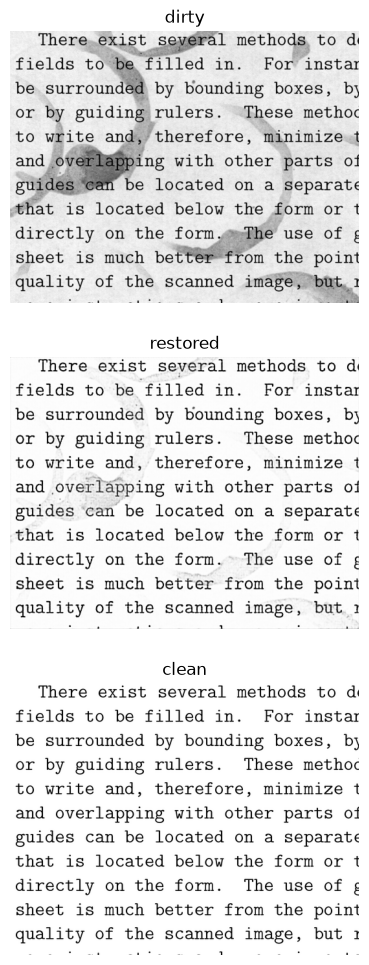

In [29]:
# ConvDenoiser → ImprovedDenoiser_1 : 모델 구조 이름 / model → improved_model_1 : 실제 모델 변수 / optimizer → improved_optimizer_1 : 개선 모델을 학습시키는 도구

def denoise_full_image(improved_model_1, img_tensor, multiple=4):
    """크기가 4의 배수가 아니면 오른쪽/아래를 패딩한 뒤 복원하고, 원래 크기로 되돌립니다."""
    _, h, w = img_tensor.shape
    pad_h = (multiple - h % multiple) % multiple
    pad_w = (multiple - w % multiple) % multiple
    x = F.pad(img_tensor.unsqueeze(0), (0, pad_w, 0, pad_h), mode="reflect")
    improved_model_1.eval()
    with torch.no_grad():
        out = improved_model_1(x.to(device)).cpu()
    return out[0, :, :h, :w]


# 훈련 이미지 하나를 통째로 복원해 봅니다.
name = full_dataset.files[val_dataset.indices[0]]
dirty_full = TF.to_tensor(Image.open(TRAIN_DIR / name).convert("L"))
clean_full = TF.to_tensor(Image.open(CLEAN_DIR / name).convert("L"))
restored_full = denoise_full_image(improved_model_1, dirty_full)

rmse = torch.sqrt(((restored_full - clean_full) ** 2).mean())
print(f"RMSE: {rmse:.4f}")

fig, axes = plt.subplots(3, 1, figsize=(10, 12))
for ax, img, title in zip(axes, [dirty_full, restored_full, clean_full], ["dirty", "restored", "clean"]):
    ax.imshow(img.squeeze(), cmap="gray"); ax.set_title(title); ax.axis("off")
plt.show()

스킵 추가 층 2, 에폭 30 : 기본 성능과 큰 loss 차이는 없으나 성능은 더 좋음, restored에서도 글씨가 보임, RMSE 0.0523

스킵 추가 층 2, 에폭 50 : 45에서 loss 계산이 멈춰짐, RMSE  0.0403

기본 2층은 RMSE 0.0575 -> 스킵 추가는 0.0458 로 스킵을 통해서 인코더가 중간정보를 디코더로 직접 전달하면, 압축과정에서 잃기 쉬운 세부 정보를 직접 디코더로 전달해 기본 2층보다 글자정보를 복원하는데 도움이 된다.

In [30]:
# TEST 전 확인
test_files = sorted(TEST_DIR.glob("*.png"))

print("테스트 이미지 수:", len(test_files))
print("첫 번째 파일:", test_files[0].name)

테스트 이미지 수: 72
첫 번째 파일: 1.png


In [35]:
test_path = test_files[1]

dirty_test = TF.to_tensor(
    Image.open(test_path).convert("L")
)

print("테스트 이미지 모양:", dirty_test.shape)

테스트 이미지 모양: torch.Size([1, 258, 540])


In [37]:
restored_test = denoise_full_image(
    model,
    dirty_test,
    multiple=4
)

print("복원 이미지 모양:", restored_test.shape)

복원 이미지 모양: torch.Size([1, 258, 540])


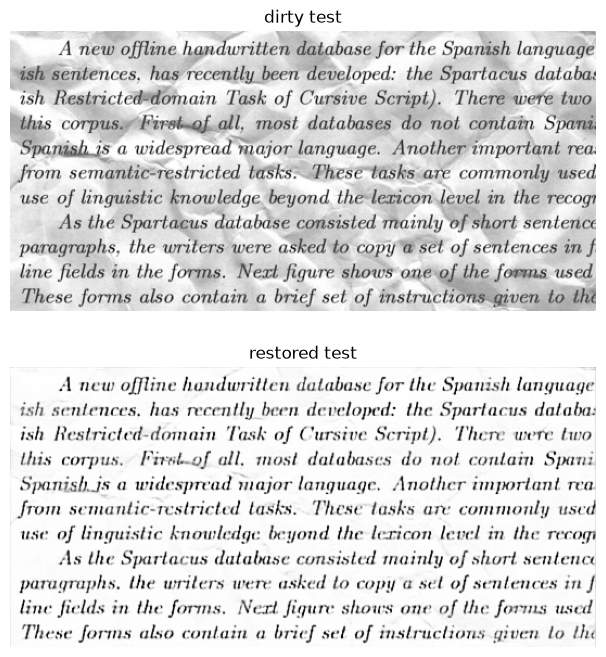

In [38]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].imshow(dirty_test.squeeze(), cmap="gray")
axes[0].set_title("dirty test")
axes[0].axis("off")

axes[1].imshow(restored_test.squeeze(), cmap="gray")
axes[1].set_title("restored test")
axes[1].axis("off")

plt.show()

# 테스트 이미지 복원 결과, 전체적인 얼룩은 감소했지만 일부 주름 형태의 노이즈가 남았다. 좌우 반전 증강만으로는 다양한 주름 손상을 학습하는 데 한계가 있는 것으로 보인다.

---
# Part 2. (심화) 심전도 이상 탐지 — LSTM 오토인코더

심화 문제는 채점에 포함되지 않아요. 여유가 될 때 도전해 봅시다.

이번에는 순서가 있는 데이터입니다. **정상 심전도(ECG) 신호만으로** LSTM 오토인코더를 학습시킵니다.
정상 패턴만 배운 모델은 이상 신호를 제대로 복원하지 못하므로, **복원 오차가 큰 신호를 이상 심박으로 판정**할 수 있어요.

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv", header=None)
data = df.iloc[:, :-1].values.astype("float32")  # (4998, 140) — 신호 하나당 140 타임스텝
labels = df.iloc[:, -1].values.astype(int)       # 1: 정상, 0: 이상

X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42, stratify=labels
)

# 훈련 데이터 기준으로 0~1 정규화
mn, mx = X_train.min(), X_train.max()
X_train = (X_train - mn) / (mx - mn)
X_test = (X_test - mn) / (mx - mn)

# 핵심: 정상 신호만 골라 학습 세트를 만듭니다.
X_train_normal = X_train[y_train == 1]
print("전체 훈련:", X_train.shape, "| 정상만:", X_train_normal.shape, "| 테스트:", X_test.shape)

전체 훈련: (3998, 140) | 정상만: (2335, 140) | 테스트: (1000, 140)


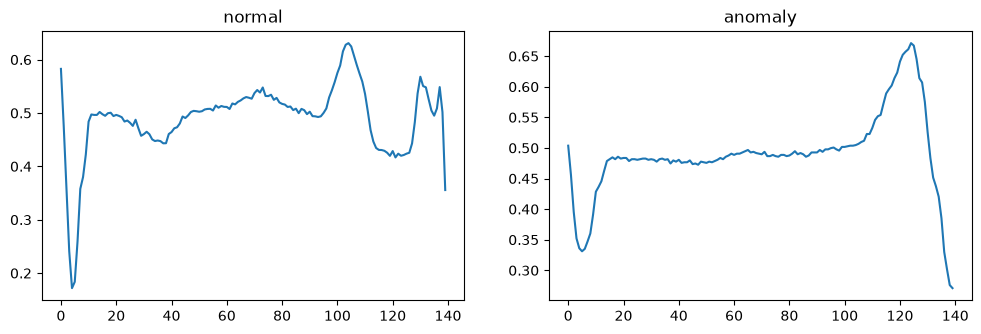

In [27]:
# 정상 신호와 이상 신호를 눈으로 비교해 봅시다.
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(X_train[y_train == 1][0]); axes[0].set_title("normal")
axes[1].plot(X_train[y_train == 0][0]); axes[1].set_title("anomaly")
plt.show()

## 2-1. LSTM 오토인코더 설계
인코더 LSTM의 **마지막 hidden state**가 신호 전체를 요약한 잠재 벡터가 됩니다.
디코더는 이 벡터를 타임스텝 수만큼 반복해 입력받아, 원래 신호를 되살려 냅니다.

In [ ]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, seq_len=140, n_features=1, hidden_size=64):
        super().__init__()
        self.seq_len = seq_len
        self.encoder = nn.LSTM(n_features, hidden_size, batch_first=True)
        self.decoder = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.output_layer = nn.Linear(hidden_size, n_features)

    def forward(self, x):
        # x: (batch, 140, 1)
        _, (h, _) = self.encoder(x)                          # h: (1, batch, 64) — 신호 전체의 요약
        z = h[-1]                                            # (batch, 64)
        dec_in = z.unsqueeze(1).repeat(1, self.seq_len, 1)   # (batch, 140, 64)
        out, _ = self.decoder(dec_in)                        # (batch, 140, 64)
        return self.output_layer(out)                        # (batch, 140, 1)


ae = LSTMAutoencoder().to(device)
print(ae)

LSTMAutoencoder(
  (encoder): LSTM(1, 64, batch_first=True)
  (decoder): LSTM(64, 64, batch_first=True)
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
)


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

X_train_normal_t = torch.tensor(X_train_normal).unsqueeze(-1)  # (N, 140, 1)
normal_loader = DataLoader(TensorDataset(X_train_normal_t), batch_size=128, shuffle=True)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3)

EPOCHS = 100
for epoch in range(EPOCHS):
    ae.train()
    epoch_loss = 0.0
    for (xb,) in normal_loader:
        xb = xb.to(device)
        optimizer.zero_grad()
        loss = criterion(ae(xb), xb)  # 입력을 그대로 복원하도록 학습
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    if (epoch + 1) % 20 == 0:
        print(f"epoch {epoch + 1:3d} | loss {epoch_loss / len(X_train_normal_t):.5f}")

epoch  20 | loss 0.00318
epoch  40 | loss 0.00262
epoch  60 | loss 0.00213
epoch  80 | loss 0.00166
epoch 100 | loss 0.00154


## 2-2. 복원 오차 분포와 임계값
정상 훈련 신호의 복원 오차 분포를 기준으로 임계값을 정합니다.
Baseline은 `평균 + 2×표준편차`를 사용했지만, 백분위수(예: 95%) 등 다른 기준도 실험해 보세요.

임계값: 0.00334


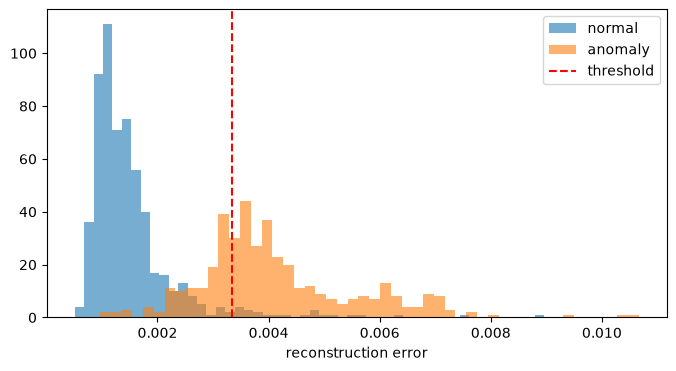

In [ ]:
def recon_errors(model, X):
    """신호별 복원 오차(MSE)를 계산합니다."""
    model.eval()
    x = torch.tensor(X).unsqueeze(-1)
    with torch.no_grad():
        pred = model(x.to(device)).cpu()
    return ((pred - x) ** 2).mean(dim=(1, 2)).numpy()


train_errors = recon_errors(ae, X_train_normal)
threshold = train_errors.mean() + 2 * train_errors.std()
print(f"임계값: {threshold:.5f}")

# 테스트 세트에서 정상/이상의 오차 분포가 갈라지는지 확인해 봅시다.
test_errors = recon_errors(ae, X_test)
plt.figure(figsize=(8, 4))
plt.hist(test_errors[y_test == 1], bins=50, alpha=0.6, label="normal")
plt.hist(test_errors[y_test == 0], bins=50, alpha=0.6, label="anomaly")
plt.axvline(threshold, color="red", linestyle="--", label="threshold")
plt.xlabel("reconstruction error"); plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# 오차가 임계값보다 크면 이상(0), 작으면 정상(1)으로 판정합니다.
y_pred = (test_errors <= threshold).astype(int)
print(classification_report(y_test, y_pred, target_names=["anomaly(0)", "normal(1)"], digits=3))

              precision    recall  f1-score   support

  anomaly(0)      0.927     0.702     0.799       416
   normal(1)      0.819     0.961     0.884       584

    accuracy                          0.853      1000
   macro avg      0.873     0.831     0.842      1000
weighted avg      0.864     0.853     0.849      1000



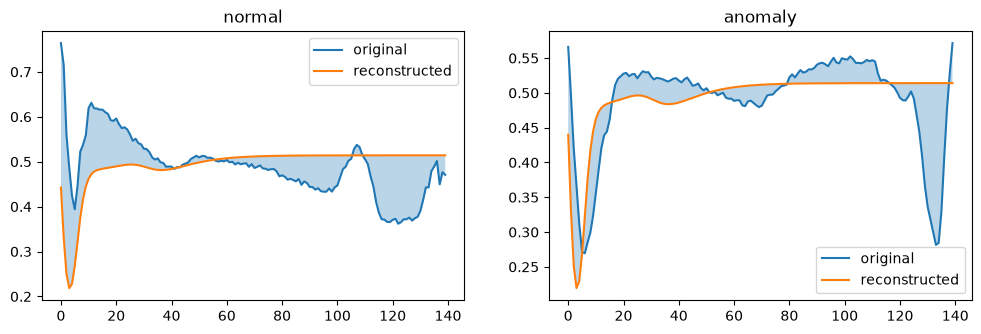

In [ ]:
# 모델이 이상 신호를 '못' 복원하는 모습을 직접 확인해 봅시다.
def plot_reconstruction(model, signal, title):
    x = torch.tensor(signal).reshape(1, -1, 1)
    with torch.no_grad():
        pred = model(x.to(device)).cpu().squeeze()
    plt.plot(signal, label="original")
    plt.plot(pred, label="reconstructed")
    plt.fill_between(range(len(signal)), signal, pred, alpha=0.3)
    plt.title(title); plt.legend()


plt.figure(figsize=(12, 3.5))
plt.subplot(1, 2, 1); plot_reconstruction(ae, X_test[y_test == 1][0], "normal")
plt.subplot(1, 2, 2); plot_reconstruction(ae, X_test[y_test == 0][0], "anomaly")
plt.show()

## 2-3. 더 실험해 볼 것들
- 임계값 기준을 바꿔 보며 Precision과 Recall이 어떻게 움직이는지 관찰하기
- hidden size, 층 수를 조절하거나 LSTM을 GRU로 바꿔 비교하기
- 인코더를 양방향(bidirectional)으로 바꾸면 복원 품질이 달라지는지 확인하기

기본 미션과 심화 문제 모두 하나의 노트북에 담아 `05_{팀명}_{성함}.ipynb`로 제출해 주세요.